# Notebook 05 — Volatility Surfaces & Option Pricing

## Fixed Income From Scratch

**Objective:** Build the volatility infrastructure that feeds into the Monte Carlo interest rate model.

### What We'll Cover:
1. **Black Model** — Closed-form pricing for European swaptions, caps, floors
2. **Swaption Volatility Surface** — The 3D object (expiry × tenor × strike) 
3. **SABR Model** — Stochastic volatility model for the smile/skew
4. **Cap/Floor Vols** — Flat-to-spot vol stripping
5. **Calibration** — Fitting SABR to market smile data

### Why This Matters:
- Swaption vols constrain the **factor volatilities** in the BGM/Hull-White model (Notebook 06)
- Vol levels directly affect **option cost** in OAS (higher vol = more expensive prepayment option)
- **Volatility duration** measures how OAS-price changes with vol shifts
- The vol surface is a key input to **scenario analysis** (vol shocks)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.ticker as mticker
import sys, os

sys.path.insert(0, os.path.abspath('..'))
from utils.volatility import (
    black76_call, black76_put, bachelier_call, bachelier_put,
    swaption_price, sabr_implied_vol, sabr_normal_vol, calibrate_sabr,
    SwaptionVolSurface, generate_synthetic_swaption_surface,
    generate_synthetic_sabr_params, price_cap, price_caplet, strip_cap_vols
)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

print("Volatility modules loaded.")

Volatility modules loaded.


---
## 1. Black Model — Foundation of Rates Option Pricing

The Black-76 model prices European options on forward rates. For a **payer swaption** (right to pay fixed):

$$P = A \times [F \cdot N(d_1) - K \cdot N(d_2)]$$

where $d_1 = \frac{\ln(F/K) + \frac{1}{2}\sigma^2 T}{\sigma\sqrt{T}}$, $A$ = annuity factor, $F$ = forward swap rate.

The **Bachelier (normal) model** uses additive rather than multiplicative vol — essential when rates can go negative:

$$P = A \times [(F-K)N(d) + \sigma_N\sqrt{T} \cdot n(d)]$$

Normal vols are quoted in **basis points** (e.g., 80bp). Lognormal vols are quoted as percentages (e.g., 20%).

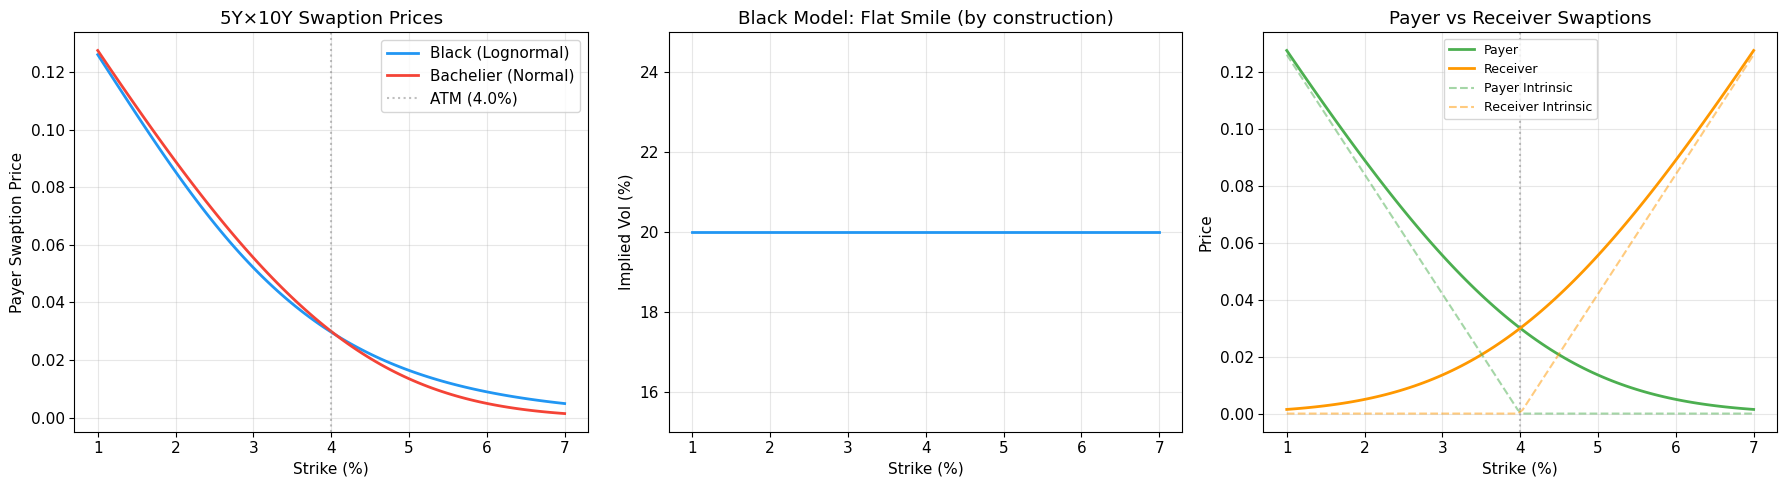

In [4]:
# Compare Black vs Bachelier across strikes
forward = 0.04  # 4% forward swap rate
expiry = 5.0
annuity = 4.2  # PV of swap annuity (~$4.20 per $100)
lognormal_vol = 0.20  # 20%
normal_vol = 80  # 80bp

strikes = np.linspace(0.01, 0.07, 100)

# Lognormal prices
black_prices = [swaption_price(forward, k, lognormal_vol, expiry, annuity, True, 'lognormal') for k in strikes]
# Normal prices
normal_prices = [swaption_price(forward, k, normal_vol, expiry, annuity, True, 'normal') for k in strikes]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Swaption prices
ax = axes[0]
ax.plot(strikes * 100, black_prices, linewidth=2, label='Black (Lognormal)', color='#2196F3')
ax.plot(strikes * 100, normal_prices, linewidth=2, label='Bachelier (Normal)', color='#F44336')
ax.axvline(x=forward*100, color='gray', linestyle=':', alpha=0.5, label=f'ATM ({forward*100}%)')
ax.set_xlabel('Strike (%)')
ax.set_ylabel('Payer Swaption Price')
ax.set_title('5Y×10Y Swaption Prices')
ax.legend()

# Implied vols from Black model
ax = axes[1]
black_vols_by_strike = []
for k in strikes:
    if k > 0.005:
        d1 = (np.log(forward/k) + 0.5*lognormal_vol**2*expiry)/(lognormal_vol*np.sqrt(expiry))
        black_vols_by_strike.append(lognormal_vol * 100)
    else:
        black_vols_by_strike.append(np.nan)
ax.plot(strikes*100, black_vols_by_strike, linewidth=2, color='#2196F3')
ax.set_xlabel('Strike (%)')
ax.set_ylabel('Implied Vol (%)')
ax.set_title('Black Model: Flat Smile (by construction)')
ax.set_ylim(15, 25)

# Payer vs Receiver
ax = axes[2]
payer = [swaption_price(forward, k, normal_vol, expiry, annuity, True, 'normal') for k in strikes]
receiver = [swaption_price(forward, k, normal_vol, expiry, annuity, False, 'normal') for k in strikes]
intrinsic_payer = [max(forward - k, 0) * annuity for k in strikes]
intrinsic_recv = [max(k - forward, 0) * annuity for k in strikes]
ax.plot(strikes*100, payer, linewidth=2, label='Payer', color='#4CAF50')
ax.plot(strikes*100, receiver, linewidth=2, label='Receiver', color='#FF9800')
ax.plot(strikes*100, intrinsic_payer, '--', alpha=0.5, label='Payer Intrinsic', color='#4CAF50')
ax.plot(strikes*100, intrinsic_recv, '--', alpha=0.5, label='Receiver Intrinsic', color='#FF9800')
ax.axvline(x=forward*100, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Strike (%)')
ax.set_ylabel('Price')
ax.set_title('Payer vs Receiver Swaptions')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 2. Swaption Volatility Surface

The swaption vol surface is a 2D grid of ATM normal volatilities indexed by option expiry and underlying swap tenor. This surface encodes the market's view on future rate uncertainty.

**Key patterns:**
- **Short expiry, short tenor** = highest vols (near-term rate uncertainty)
- **Long expiry** = lower vols (mean reversion dampens long-horizon uncertainty)
- **Medium tenor (5-10Y)** = highest vols within each expiry row (the "belly" of the curve has most uncertainty)

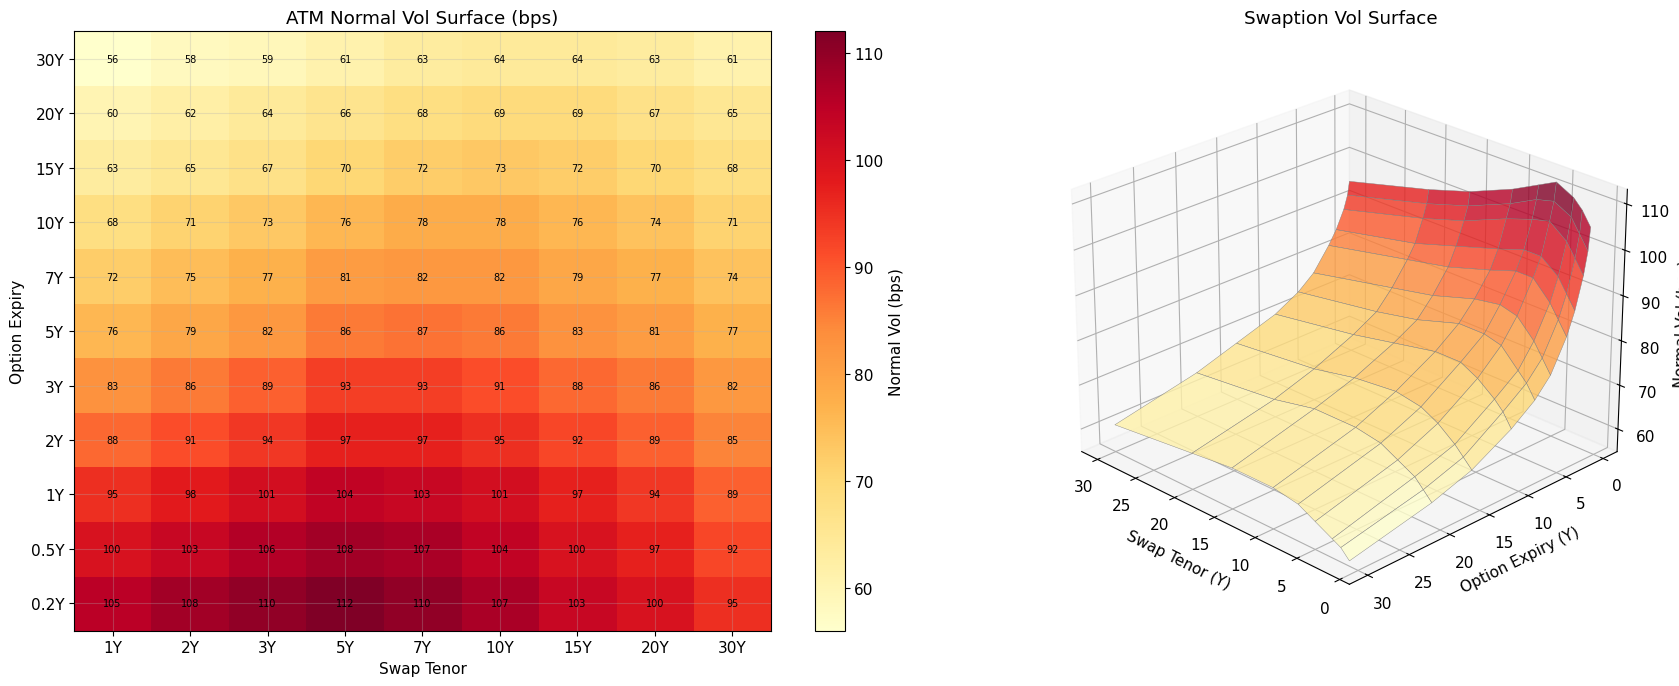

Key ATM Normal Vols (bps):
  1Y×5Y: 104.0bp
  1Y×10Y: 101.0bp
  1Y×30Y: 89.0bp
  5Y×5Y: 86.0bp
  5Y×10Y: 86.0bp
  5Y×30Y: 77.0bp
  10Y×5Y: 76.0bp
  10Y×10Y: 78.0bp
  10Y×30Y: 71.0bp


In [6]:
# Generate and visualize the swaption vol surface
surface = generate_synthetic_swaption_surface()

# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
im = ax.imshow(surface.atm_vols, aspect='auto', cmap='YlOrRd', origin='lower')
ax.set_xticks(range(len(surface.tenors)))
ax.set_xticklabels([f'{t:.0f}Y' for t in surface.tenors])
ax.set_yticks(range(len(surface.expiries)))
ax.set_yticklabels([f'{e:.1f}Y' if e < 1 else f'{e:.0f}Y' for e in surface.expiries])
ax.set_xlabel('Swap Tenor')
ax.set_ylabel('Option Expiry')
ax.set_title('ATM Normal Vol Surface (bps)')
plt.colorbar(im, ax=ax, label='Normal Vol (bps)')
for i in range(len(surface.expiries)):
    for j in range(len(surface.tenors)):
        ax.text(j, i, f'{surface.atm_vols[i,j]:.0f}', ha='center', va='center', fontsize=7)

# 3D surface
ax = axes[1]
ax.remove()
ax = fig.add_subplot(122, projection='3d')
X, Y = np.meshgrid(surface.tenors, surface.expiries)
ax.plot_surface(X, Y, surface.atm_vols, cmap='YlOrRd', alpha=0.8, edgecolors='gray', linewidth=0.3)
ax.set_xlabel('Swap Tenor (Y)')
ax.set_ylabel('Option Expiry (Y)')
ax.set_zlabel('Normal Vol (bps)')
ax.set_title('Swaption Vol Surface')
ax.view_init(elev=25, azim=135)

plt.tight_layout()
plt.show()

# Print key vols
print("Key ATM Normal Vols (bps):")
for exp in [1, 5, 10]:
    for ten in [5, 10, 30]:
        v = surface.get_vol(exp, ten)
        print(f"  {exp}Y×{ten}Y: {v:.1f}bp")

---
## 3. SABR Smile Model

The Black model assumes **flat implied vol across strikes** (no smile/skew). In reality, out-of-the-money options trade at different implied vols than ATM. The SABR model captures this:

$$dF = \alpha F^\beta dW_1, \quad d\alpha = \nu \alpha dW_2, \quad \langle dW_1, dW_2 \rangle = \rho dt$$

Parameters:
- **α (alpha)**: ATM vol level
- **β (beta)**: backbone parameter (0=normal, 1=lognormal). Fixed at 0.5 for rates.
- **ρ (rho)**: rate-vol correlation. **Negative ρ** creates the typical rates skew (receiver swaptions more expensive than payers at equivalent moneyness)
- **ν (nu)**: vol-of-vol. Higher ν = fatter smile tails

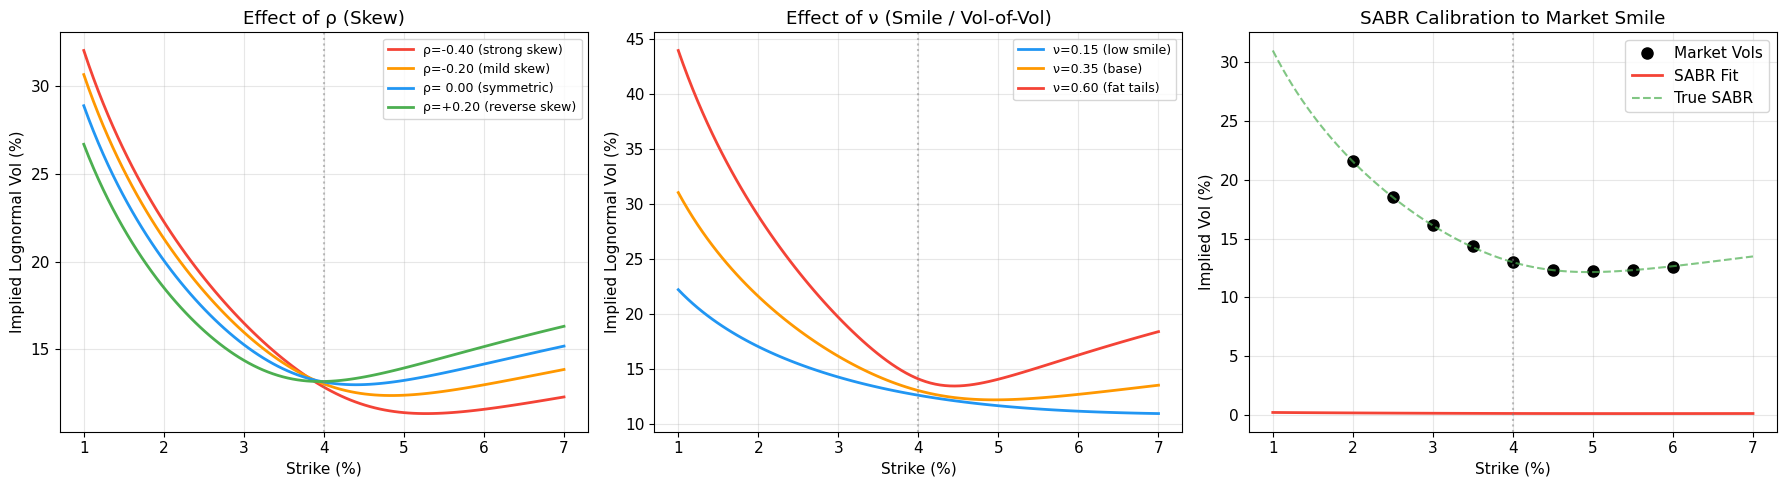

Calibrated SABR: α=0.0251, ρ=-0.252, ν=0.349
True params:     α=0.0250, ρ=-0.250, ν=0.350
Calibration RMSE: 0.0476%


In [8]:
# Demonstrate SABR smile
forward = 0.04
expiry = 5.0

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Effect of rho (skew)
ax = axes[0]
strikes_plot = np.linspace(0.01, 0.07, 100)  
for rho, color, label in [(-0.40, '#F44336', 'ρ=-0.40 (strong skew)'),
                            (-0.20, '#FF9800', 'ρ=-0.20 (mild skew)'),
                            (0.0, '#2196F3', 'ρ= 0.00 (symmetric)'),
                            (0.20, '#4CAF50', 'ρ=+0.20 (reverse skew)')]:
    vols = [sabr_implied_vol(forward, k, expiry, 0.025, 0.5, rho, 0.35) * 100 
            for k in strikes]
    ax.plot(strikes*100, vols, linewidth=2, label=label, color=color)
ax.axvline(x=forward*100, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Strike (%)')
ax.set_ylabel('Implied Lognormal Vol (%)')
ax.set_title('Effect of ρ (Skew)')
ax.legend(fontsize=9)

# Effect of nu (smile)
ax = axes[1]
for nu, color, label in [(0.15, '#2196F3', 'ν=0.15 (low smile)'),
                           (0.35, '#FF9800', 'ν=0.35 (base)'),
                           (0.60, '#F44336', 'ν=0.60 (fat tails)')]:
    vols = [sabr_implied_vol(forward, k, expiry, 0.025, 0.5, -0.25, nu) * 100
            for k in strikes]
    ax.plot(strikes*100, vols, linewidth=2, label=label, color=color)
ax.axvline(x=forward*100, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Strike (%)')
ax.set_ylabel('Implied Lognormal Vol (%)')
ax.set_title('Effect of ν (Smile / Vol-of-Vol)')
ax.legend(fontsize=9)

# SABR calibration demo
ax = axes[2]
true_params = {'alpha': 0.025, 'beta': 0.5, 'rho': -0.25, 'nu': 0.35}
cal_strikes = np.array([0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05, 0.055, 0.06])
market_vols = np.array([sabr_implied_vol(forward, k, expiry, **true_params) for k in cal_strikes])
# Add noise
np.random.seed(42)
market_vols_noisy = market_vols * (1 + np.random.normal(0, 0.005, len(market_vols)))

# Calibrate
result = calibrate_sabr(forward, expiry, cal_strikes, market_vols_noisy, beta=0.5)
strikes_plot = np.linspace(0.02, 0.06, 100)
fitted_vols = [sabr_implied_vol(forward, k, expiry, result['alpha'], 0.5, result['rho'], result['nu'])
               for k in strikes_plot]

ax.plot(cal_strikes*100, market_vols_noisy*100, 'ko', markersize=8, label='Market Vols')
ax.plot(strikes*100, fitted_vols, linewidth=2, label='SABR Fit', color='#F44336')
ax.plot(strikes*100, [sabr_implied_vol(forward, k, expiry, **true_params)*100 for k in strikes],
        '--', linewidth=1.5, label='True SABR', color='#4CAF50', alpha=0.7)
ax.axvline(x=forward*100, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Strike (%)')
ax.set_ylabel('Implied Vol (%)')
ax.set_title('SABR Calibration to Market Smile')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Calibrated SABR: α={result['alpha']:.4f}, ρ={result['rho']:.3f}, ν={result['nu']:.3f}")
print(f"True params:     α=0.0250, ρ=-0.250, ν=0.350")
print(f"Calibration RMSE: {result['rmse']*100:.4f}%")

---
## Summary & What's Next

### What We Built:
- **Black-76 and Bachelier** swaption/cap pricing models
- **Swaption ATM normal vol surface** with realistic term structure
- **SABR stochastic volatility model** with calibration to market smile
- Understanding of how ρ controls skew and ν controls smile curvature

### Next: Notebook 06
Monte Carlo interest rate simulation using a 3-factor Hull-White model, calibrated to the swaption vol surface. This generates the rate paths needed for OAS.